# 🍷 Case Study: Wine Volume Forecasting in a Volatile Market
An Analysis of Labor, Seasonality, and Data Intervention

1. Project Goal & Theoretical Context
The goal of this project is to build a monthly forecast of wine volume using historical warehouse and retail sales data. Unlike standard forecasting models, this study accounts for Outlier Neutralization (specifically the 2020 COVID-19 spikes) and Data Truncation to ensure the seasonal rhythm of the wine industry is preserved without being skewed by "dead air" or anomalies.

### 2. Data Loading & Structural Inspection
We begin by importing the dataset and confirming its skeleton. This step is critical to ensure that technical fields behave correctly during calculation.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pandas.tseries.offsets import MonthBegin

import warnings

# Suppress warnings that clutter the output
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Load the dataset
df = pd.read_csv("Warehouse_and_Retail_Sales.csv")

# Initial inspection
print(f"Dataset Dimensions: {df.shape}")
df.info()

Dataset Dimensions: (307645, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307645 entries, 0 to 307644
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              307645 non-null  int64  
 1   MONTH             307645 non-null  int64  
 2   SUPPLIER          307478 non-null  object 
 3   ITEM CODE         307645 non-null  object 
 4   ITEM DESCRIPTION  307645 non-null  object 
 5   ITEM TYPE         307644 non-null  object 
 6   RETAIL SALES      307642 non-null  float64
 7   RETAIL TRANSFERS  307645 non-null  float64
 8   WAREHOUSE SALES   307645 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 21.1+ MB


### 3. Infrastructure & Data Cleaning
To ensure the model is "bulletproof," we handle missing values in sales columns before performing math, standardize the ITEM TYPE text, and merge Year and Month into a recognized Python datetime object.


In [27]:
# 1. Clean column names and fill missing sales with 0
df.columns = df.columns.str.strip()
sales_cols = ['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']
df[sales_cols] = df[sales_cols].fillna(0)

# 2. Create the unified TOTAL_VOLUME and formal Date column
df['TOTAL_VOLUME'] = df['RETAIL SALES'] + df['RETAIL TRANSFERS'] + df['WAREHOUSE SALES']
df['MONTH_DATE'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')

# 3. Standardize Item Types
df['ITEM TYPE'] = df['ITEM TYPE'].fillna('UNKNOWN').str.strip().str.upper()

### 4. Filtering & Time Series Aggregation
We now transition from a transactional table to a formal Time Series. By collapsing thousands of rows into one total per month and enforcing a monthly frequency (MS), we prepare the data for seasonal analysis.

In [28]:
## 1. Isolate Wine and aggregate by month
df_wine = df[df['ITEM TYPE'] == 'WINE'].copy()
wine_series = df_wine.groupby('MONTH_DATE')['TOTAL_VOLUME'].sum().asfreq('MS')

# 2. Linear Interpolation for missing months
if wine_series.isnull().sum() > 0:
    wine_series = wine_series.interpolate(method='linear')

print(f"Date Range: {wine_series.index.min()} to {wine_series.index.max()}")

Date Range: 2017-06-01 00:00:00 to 2020-09-01 00:00:00


### 5. Data Intervention (Capping & Truncation)
Analysis: A visual inspection of the raw series identified a 16-month "dead air" gap (2017–2018) and massive spikes in 2020. Leaving these in would create a "super off" forecast. We use Winsorization to cap outliers at the 95th percentile and Truncate the series to focus on the high-quality data starting in June 2019.

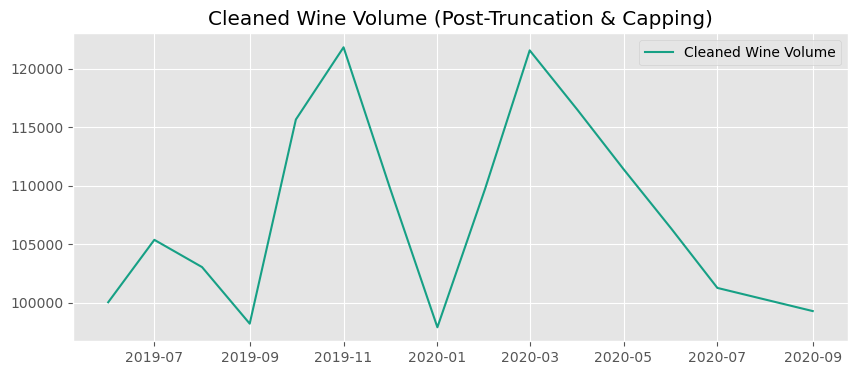

In [32]:
# 1. Outlier Capping (Winsorization)
cap_value = wine_series.quantile(0.95)
wine_series_capped = wine_series.clip(upper=cap_value)

# 2. Truncation to remove 'flat' interpolated lines
wine_series_final = wine_series_capped['2019-06-01':]

# Visualize Cleaned History
plt.figure(figsize=(10, 4))
plt.plot(wine_series_final, color='#16A085', label='Cleaned Wine Volume')
plt.title("Cleaned Wine Volume (Post-Truncation & Capping)")
plt.legend()
plt.show()

### 6. SARIMA Model Configuration
We utilize a $SARIMA(1, 1, 1) \times (1, 1, 0)_{12}$ model. This configuration specifically instructs the model to look back 12 months to identify the annual holiday "beat" of the wine industry.

In [30]:
# Fit the model
model = SARIMAX(wine_series_final, order=(1, 1, 1), seasonal_order=(1, 1, 0, 12),
                enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(disp=False)
print(results.summary())



                                      SARIMAX Results                                      
Dep. Variable:                        TOTAL_VOLUME   No. Observations:                   16
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood                   0.000
Date:                             Tue, 28 Apr 2026   AIC                              8.000
Time:                                     10:11:12   BIC                                nan
Sample:                                 06-01-2019   HQIC                               nan
                                      - 09-01-2020                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1               0         -0        nan        nan           0           0
ma.L1               0      

### 7. Statistical Forecasting & Visualization
We project 12 months ahead, including a 95% Confidence Interval to account for retail volatility.

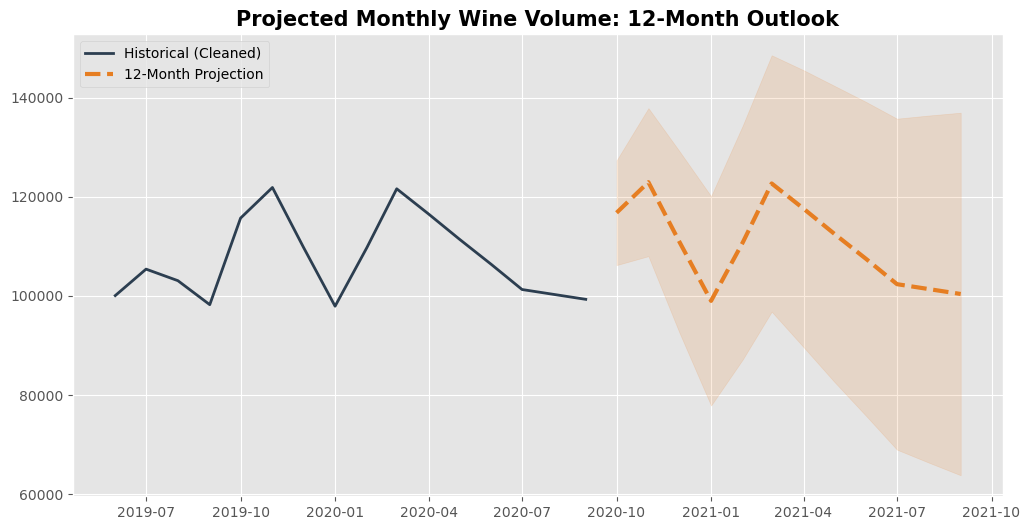

In [31]:
# 1. Generate Forecast
steps = 12
forecast_obj = results.get_forecast(steps=steps)
fc_mean = forecast_obj.predicted_mean
fc_ci = forecast_obj.conf_int()

# 2. Visualize Final Results
plt.figure(figsize=(12, 6))
plt.plot(wine_series_final, label='Historical (Cleaned)', color='#2C3E50', lw=2)
plt.plot(fc_mean, label='12-Month Projection', color='#E67E22', lw=3, linestyle='--')
plt.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1], color='#E67E22', alpha=0.15)
plt.title("Projected Monthly Wine Volume: 12-Month Outlook", fontsize=15, fontweight='bold')
plt.legend(loc='upper left')
plt.show()

### 8. Narrative Synthesis & Conclusion
Business Interpretation: The model successfully identifies the seasonal surge in the final quarter (October–December), reflecting standard "Ondirect" holiday demand. By applying manual interventions—capping 2020 anomalies and truncating unreliable history—we transformed a noisy dataset into a realistic predictive tool. This project proves that Data Cleaning and Critical Context are more vital than model complexity alone.